In [1]:
# Copied imports from oppgave 1, will remove as we see something is not needed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

In [2]:
data = pd.read_csv("./Datasets/diabetes_binary_classification_data.csv")


trainData, testData = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data['Diabetes_binary']
)

def proportions(s: pd.Series):
    return s.value_counts(normalize=True).sort_index()

prop_table = pd.DataFrame({
    'overall': proportions(data['Diabetes_binary']),
    'train':   proportions(trainData['Diabetes_binary']),
    'test':    proportions(testData['Diabetes_binary'])
})
display(prop_table)


print("Train shape:", trainData.shape)
print("Test shape:", testData.shape)

,overall,train,test
Diabetes_binary,,,
0.0,0.860667,0.860666,0.860671
1.0,0.139333,0.139334,0.139329


Train shape: (202944, 22)
Test shape: (50736, 22)


In [3]:
dfTest = pd.DataFrame(testData)
dfTrain = pd.DataFrame(trainData)

def clean_data(df, colsToRemove, threshold=0.9):
    dfClean = df.copy()
    dfClean.drop(columns=colsToRemove, inplace=True)

    na_frac = dfClean.isna().mean()
    cols_to_drop = na_frac[na_frac > threshold].index.tolist()
    dfClean.drop(columns=cols_to_drop)
    dfCleaned = dfClean.copy()
    for col in dfClean.columns:
        if dfClean[col].dtype == 'object':
            dfCleaned[col] = dfClean[col].fillna('None')
        else:
            dfCleaned[col] = dfClean[col].fillna(dfCleaned[col].median())
    return dfCleaned

colsToRemove = []

dfTrain = clean_data(dfTrain, colsToRemove=colsToRemove)
dfTest = clean_data(dfTest, colsToRemove=colsToRemove)

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
def feature_engineering(df):

    
    colsToRemove = []
    df.drop(columns=colsToRemove, inplace=True)
    display(df.head())
    return df

dfTrain = feature_engineering(dfTrain)
dfTest = feature_engineering(dfTest)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
153147,0.0,0.0,0.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,2.0,4.0,5.0
176137,0.0,1.0,0.0,1.0,23.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,13.0,4.0,7.0
175578,0.0,1.0,1.0,1.0,29.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0
177887,0.0,1.0,1.0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,1.0,7.0,4.0,7.0
182143,0.0,0.0,1.0,1.0,16.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,7.0,5.0,1.0


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
128677,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,5.0,5.0,8.0
225051,1.0,1.0,0.0,1.0,36.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,3.0,0.0,0.0,1.0,0.0,10.0,3.0,4.0
27174,0.0,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,5.0,8.0
132371,0.0,0.0,0.0,1.0,22.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,4.0,7.0
164896,1.0,1.0,1.0,1.0,26.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,4.0,0.0,7.0,0.0,0.0,13.0,5.0,2.0


Text(0.5, 1.0, 'Total amount of each gender (Training data)')

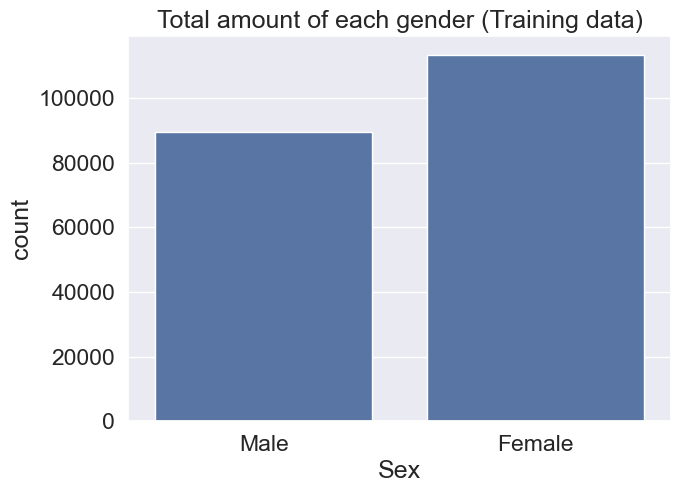

In [5]:
dfTrainWithGender = dfTrain.copy()
dfTrainWithGender['Sex'] = dfTrainWithGender['Sex'].replace({0: 'Female', 1: 'Male'})

plt.figure(figsize=(7,5))
sns.set(font_scale=1.5)
sns.countplot(x='Sex', data=dfTrainWithGender)
plt.title('Total amount of each gender (Training data)')

Text(0.5, 1.0, 'Age groups distribution by gender (Training data)')

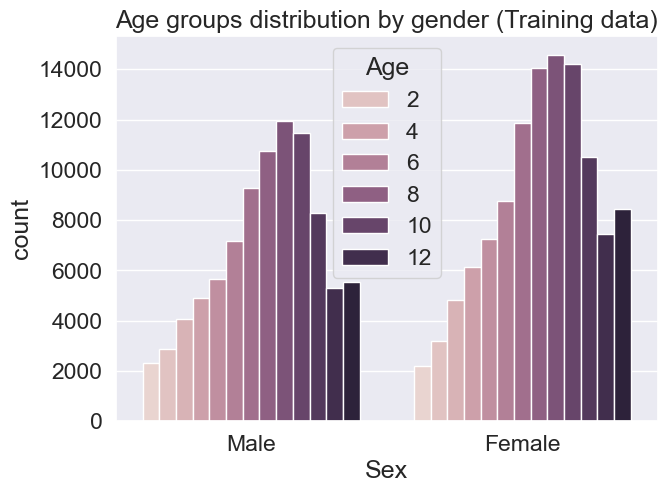

In [6]:
plt.figure(figsize=(7,5))
sns.set(font_scale=1.5)
sns.countplot(x='Sex', data=dfTrainWithGender, hue="Age")
plt.title('Age groups distribution by gender (Training data)')

Text(0.5, 1.0, 'Diabetes distribution by gender (Training data)')

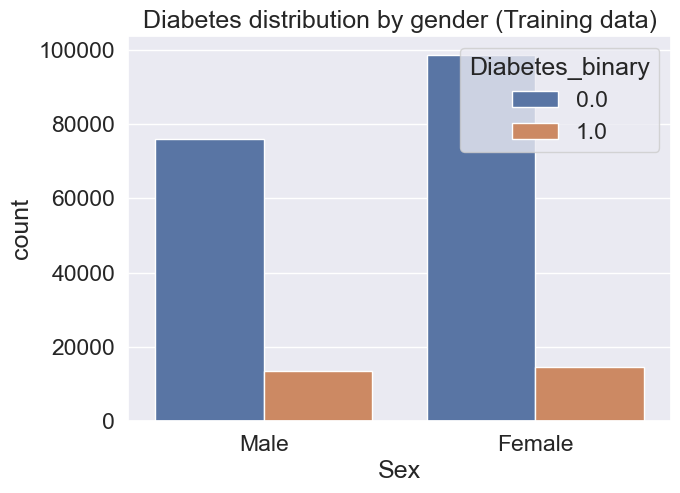

In [7]:
plt.figure(figsize=(7,5))
sns.set(font_scale=1.5)
sns.countplot(x='Sex', data=dfTrainWithGender, hue="Diabetes_binary")
plt.title('Diabetes distribution by gender (Training data)')

Text(0.5, 1.0, 'Diabetes distribution by age groups (Training data)')

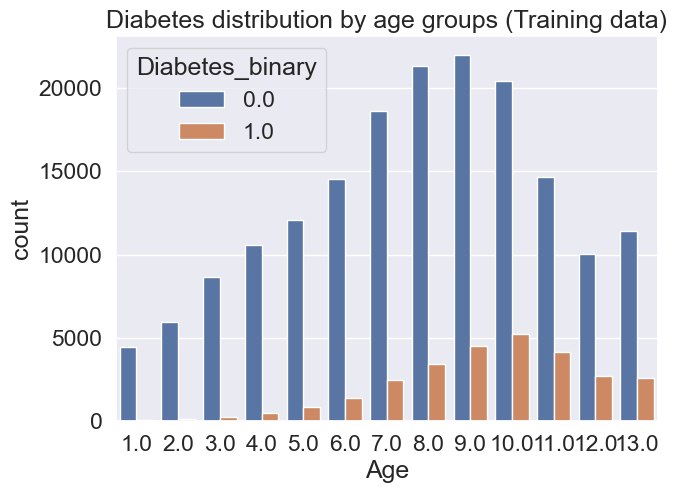

In [8]:
plt.figure(figsize=(7,5))
sns.set(font_scale=1.5)
sns.countplot(x='Age', data=dfTrain, hue="Diabetes_binary")
plt.title('Diabetes distribution by age groups (Training data)')

Text(0.5, 1.0, 'Diabetes distribution by smoker (Training data)')

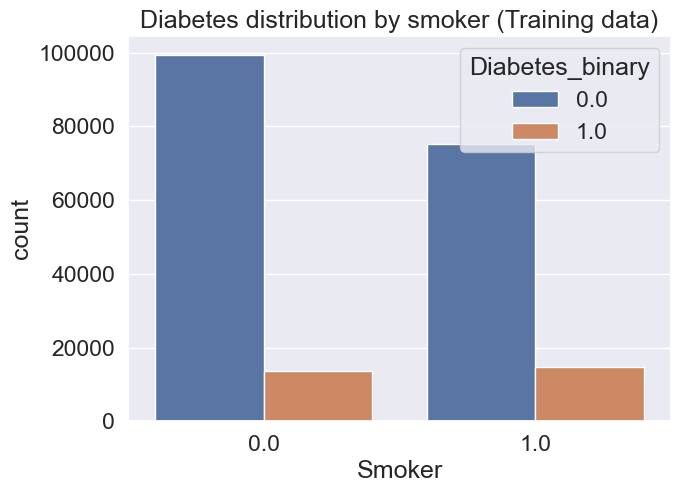

In [9]:
plt.figure(figsize=(7,5))
sns.set(font_scale=1.5)
sns.countplot(x='Smoker', data=dfTrain, hue="Diabetes_binary")
plt.title('Diabetes distribution by smoker (Training data)')

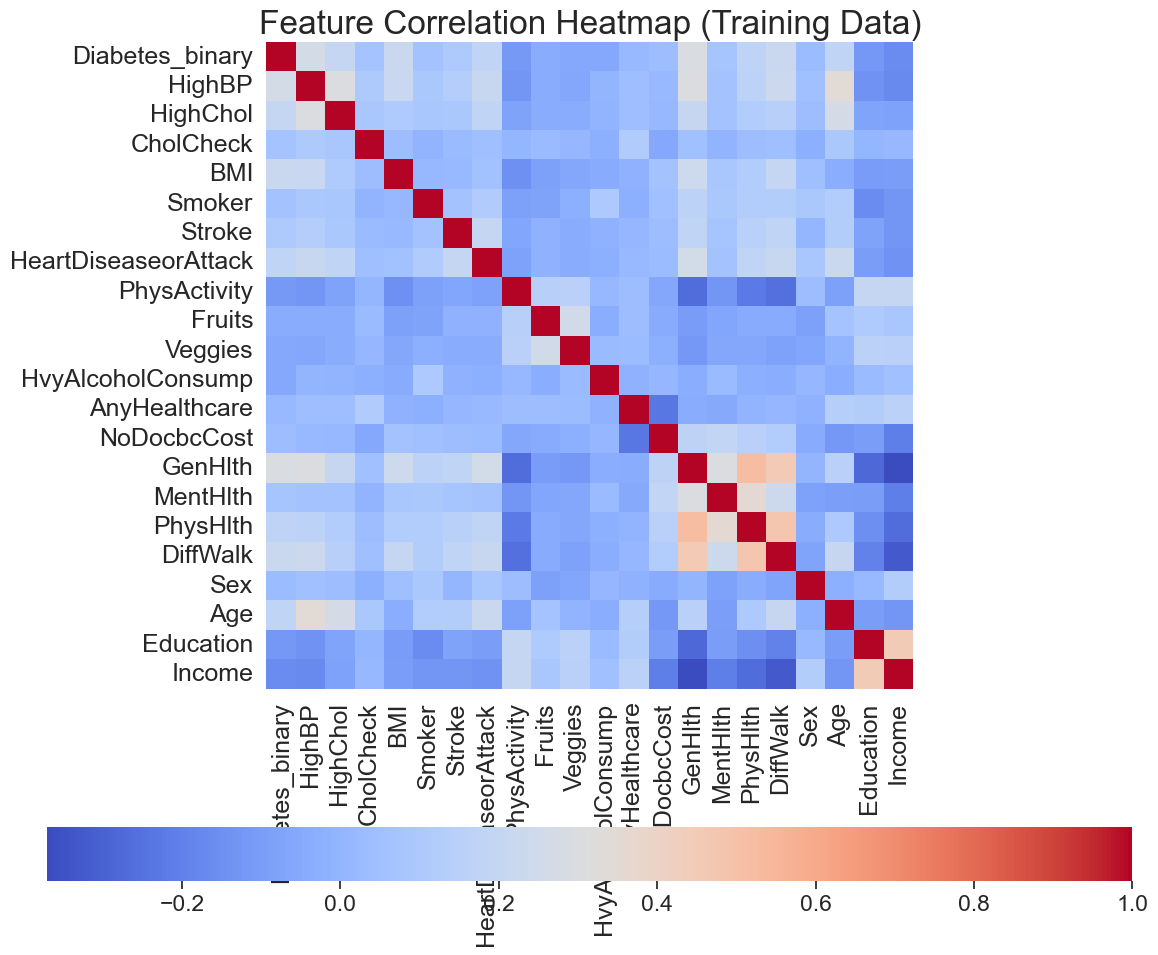

In [10]:
numeric_df = dfTrain.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 12))
ax = sns.heatmap(
    corr_matrix,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"orientation": "horizontal"}
)
plt.title("Feature Correlation Heatmap (Training Data)", fontsize=24)
plt.xticks(fontsize=18, rotation=90)
plt.yticks(fontsize=18, rotation=0)
plt.show()

In [11]:
x_train = dfTrain.drop(columns=['Diabetes_binary'])
y_train = dfTrain['Diabetes_binary']
x_test = dfTest.drop(columns=['Diabetes_binary'])
y_test = dfTest['Diabetes_binary']


print ("x_train shape:", x_train.shape)

x_train shape: (202944, 21)


In [12]:
# Balance the classes in the training set
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x_train, y_train)
X_resampled.shape, y_resampled.shape

((349334, 21), (349334,))

In [13]:
numeric_cols = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = x_train.select_dtypes(include=['object', 'category']).columns.tolist()


numeric_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transform, numeric_cols),
    ('cat', categorical_transform, categorical_cols)
])


logisticModel = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=100))
])
svmModel = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearSVC())
])
decisionTreeModel = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
])

logisticModel.fit(X_resampled, y_resampled)
svmModel.fit(X_resampled, y_resampled)
decisionTreeModel.fit(X_resampled, y_resampled)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43667
         1.0       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     43667
         1.0       0.31      0.77      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

Decision Tree Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88     43667
         1.0       0.29      0.32      0.31      7069

    accuracy                           0.80     50736
   macro avg       0.

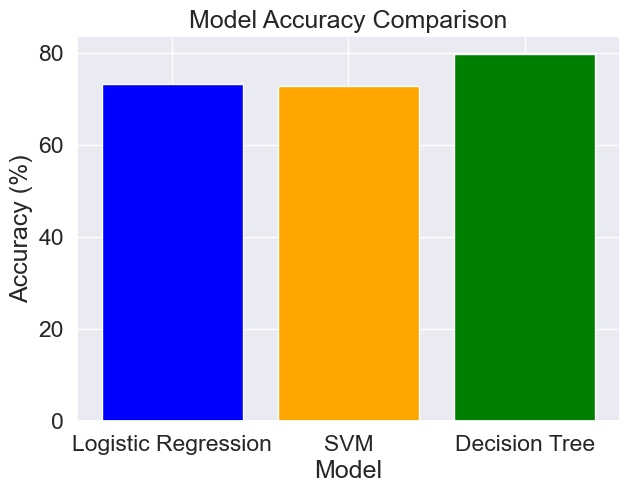

In [16]:
plt.figure(figsize=(7,5))
plt.bar(['Logistic Regression', 'SVM', 'Decision Tree'],
        [logisticModel.score(x_test, y_test) * 100, svmModel.score(x_test, y_test) * 100, decisionTreeModel.score(x_test, y_test) * 100],
        color=['blue', 'orange', 'green'])

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')


print("Logistic Regression Classification Report:")
y_pred_logistic = logisticModel.predict(x_test)
print(classification_report(y_test, y_pred_logistic))
print("SVM Classification Report:")
y_pred_svm = svmModel.predict(x_test)
print(classification_report(y_test, y_pred_svm))
print("Decision Tree Classification Report:")
y_pred_tree = decisionTreeModel.predict(x_test)
print(classification_report(y_test, y_pred_tree))
plt.show()